# Phase 2b: Model Comparison and Results

Run all predictive maintenance models on the synthetic degradation trajectory
and compare their RUL prediction accuracy, detection lead time, and false alarm rates.

Models compared:
1. **Static curve** — fit once, never adapt
2. **Rolling refit** — refit periodically on trailing window
3. **Threshold alarm** — reactive, no prediction
4. **PID adaptive drift** — adapt OEM baseline using PID feedback
5. **PID + regime detection** — PID with volatility-based regime switching

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11})

# Consistent colorblind-friendly palette matching the report
COLORS = {
    'oem_baseline': '#4682B4',   # steel blue
    'pid_adaptive': '#E69F00',   # orange
    'pid_regime': '#CC3311',     # red
    'static_curve': '#888888',   # gray
    'rolling_refit': '#228833',  # green
    'threshold_alarm': '#AA3377',# purple
    'observed': '#BBBBBB',      # light gray
}

# Display names used in the report text
DISPLAY_NAMES = {
    'static_curve': 'Static Curve',
    'rolling_refit': 'Rolling Refit',
    'threshold_alarm': 'Threshold Alarm',
    'pid_adaptive': 'PID Adaptive',
    'pid_regime': 'PID + Regime',
    'oem_baseline': 'OEM Baseline',
    'observed': 'Observed Kurtosis',
}

## 3.1 Load Data and Prepare Degradation Trajectory

In [2]:
from pathlib import Path

# Try to load pre-computed features, or build from scratch
csv_path = Path('../data/processed/inner_race_trajectory.csv')
if csv_path.exists():
    trajectory = pd.read_csv(csv_path)
    print(f'Loaded trajectory: {trajectory.shape}')
else:
    from src.feature_extraction import build_degradation_trajectory, BearingOEMParams
    bearing_params = BearingOEMParams(
        model='SKF 6205-2RS JEM', bore_mm=25.0,
        dynamic_load_rating_kn=14.8, static_load_rating_kn=7.8,
        life_exponent=3.0, bpfi=5.4152, bpfo=3.5848,
        ftf=0.39828, bsf=4.7135, max_speed_rpm=18000.0,
    )
    trajectory = build_degradation_trajectory(
        data_dir='../data/raw', fault_type='inner_race',
        load_hp=0, bearing_params=bearing_params,
    )
    print(f'Built trajectory: {trajectory.shape}')

print(f'Phases: {trajectory["phase"].value_counts().to_dict()}')

Loaded trajectory: (502, 14)
Phases: {'healthy': 202, 'mild': 100, 'moderate': 100, 'severe': 100}


## 3.2 Normalize Features and Build OEM Baseline

In [3]:
from src.oem_prior import compute_l10_hours, compute_degradation_baseline, estimate_bearing_load

# Select primary degradation feature
# Use kurtosis as it's typically the best early indicator
feature_col = 'kurtosis'
observed_raw = trajectory[feature_col].values.astype(float)
n = len(observed_raw)

# Normalize observed to [0, 1] range (0 = healthy, 1 = replacement)
obs_min = np.percentile(observed_raw, 5)  # robust min
obs_max = np.percentile(observed_raw, 95)  # robust max
if obs_max - obs_min < 1e-8:
    obs_max = obs_min + 1.0
observed = (observed_raw - obs_min) / (obs_max - obs_min)
observed = np.clip(observed, 0, None)  # allow exceeding 1.0 for severe damage

# Compute OEM baseline
P_kn = estimate_bearing_load(motor_hp=0.0, rpm=1797.0)
L10h = compute_l10_hours(C_kn=14.8, P_kn=P_kn, rpm=1797.0)
baseline = compute_degradation_baseline(L10h, n, shape='exponential')

# Define failure index (start of severe phase)
severe_mask = trajectory['phase'] == 'severe'
if severe_mask.any():
    failure_index = int(trajectory[severe_mask].index[0])
else:
    failure_index = n - 1

print(f'Feature: {feature_col}')
print(f'Trajectory length: {n}')
print(f'Failure index: {failure_index}')
print(f'L10 life: {L10h:,.0f} hours')

Feature: kurtosis
Trajectory length: 502
Failure index: 402
L10 life: 31,847,753,015 hours


## 3.3 Run All Models

In [4]:
from src.adaptive_drift import adaptive_drift_pid, adaptive_drift_with_regime, PIDParams
from src.baselines import static_degradation_curve, rolling_refit_curve, threshold_alarm
from src.evaluation import compute_actual_rul, compute_rul_metrics, compute_detection_metrics, compare_models

actual_rul = compute_actual_rul(n, failure_index)

# Model 1: Static curve
static_result = static_degradation_curve(trajectory, feature_col, fit_window=n//4)

# Model 2: Rolling refit
rolling_result = rolling_refit_curve(trajectory, feature_col, window=50, refit_every=10)

# Model 3: Threshold alarm
alarm_thresholds = {
    'warning': obs_min + 0.5 * (obs_max - obs_min),
    'alert': obs_min + 0.7 * (obs_max - obs_min),
    'danger': obs_min + 0.9 * (obs_max - obs_min),
}
alarm_result = threshold_alarm(trajectory, feature_col, alarm_thresholds)

# Model 4: PID adaptive drift
pid_result = adaptive_drift_pid(observed, baseline, PIDParams())

# Model 5: PID with regime detection
regime_result = adaptive_drift_with_regime(observed, baseline, PIDParams())

print('All models complete.')

All models complete.


## 3.4 Degradation Tracking Visualization

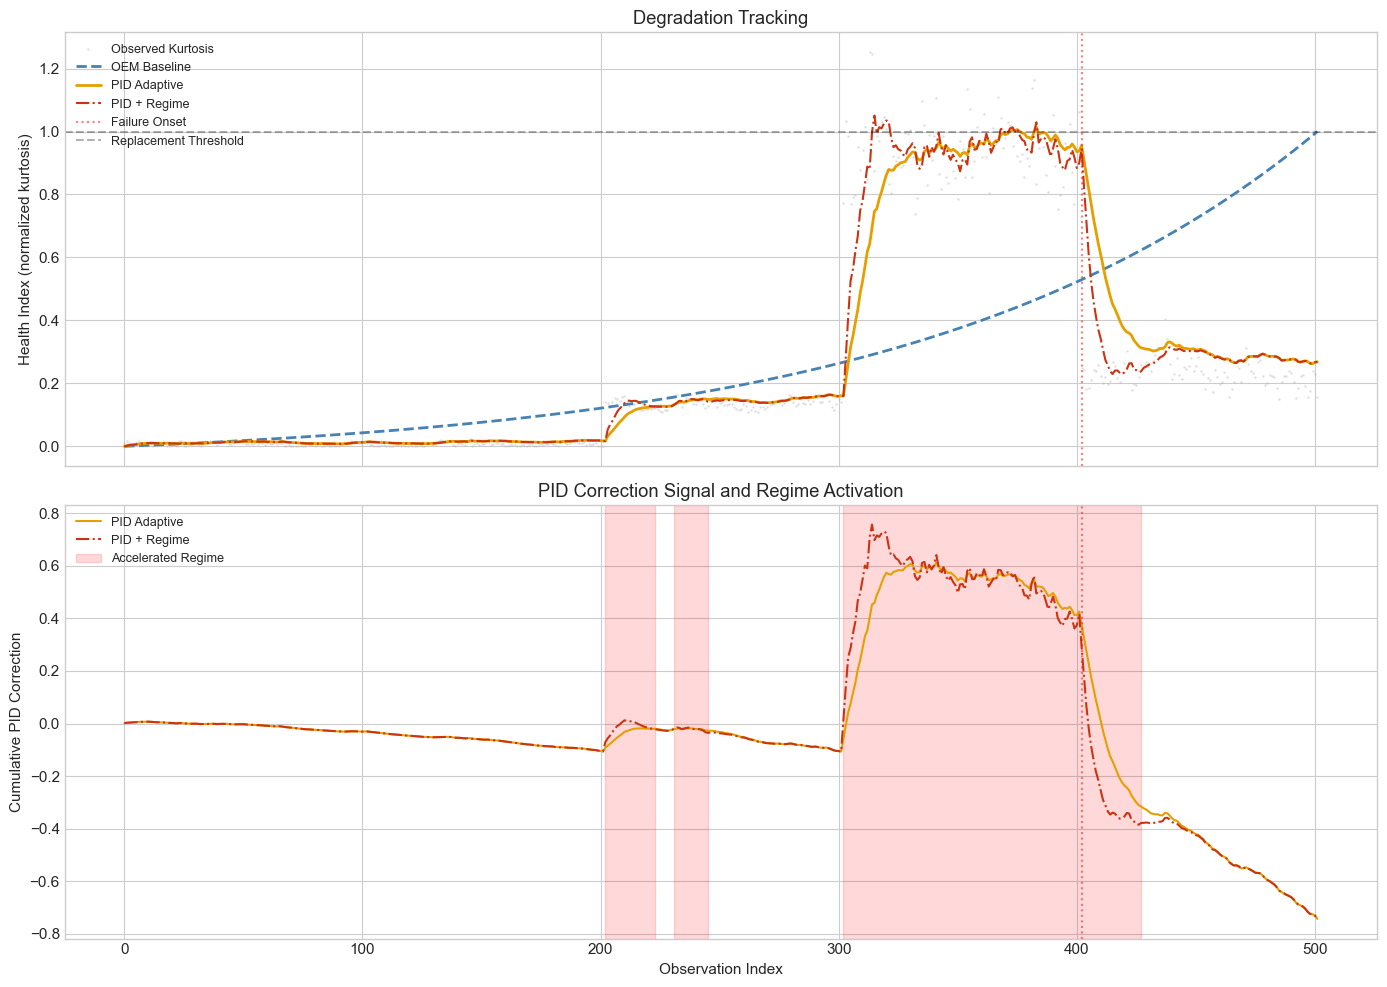

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Top panel: observed degradation vs model tracking ---
ax = axes[0]
ax.scatter(range(n), observed, s=1, alpha=0.3, color=COLORS['observed'],
           label=DISPLAY_NAMES['observed'])
ax.plot(baseline, color=COLORS['oem_baseline'], linewidth=2, linestyle='--',
        label=DISPLAY_NAMES['oem_baseline'])
ax.plot(pid_result.adjusted_baseline, color=COLORS['pid_adaptive'], linewidth=2,
        label=DISPLAY_NAMES['pid_adaptive'])
ax.plot(regime_result.adjusted_baseline, color=COLORS['pid_regime'], linewidth=1.5,
        linestyle='-.', label=DISPLAY_NAMES['pid_regime'])
ax.axvline(failure_index, color='red', linestyle=':', alpha=0.5, label='Failure Onset')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.3, label='Replacement Threshold')
ax.set_ylabel('Health Index (normalized kurtosis)')
ax.set_title('Degradation Tracking')
ax.legend(fontsize=9, loc='upper left')

# --- Bottom panel: PID correction signal and regime ---
ax = axes[1]
ax.plot(pid_result.cumulative_correction, color=COLORS['pid_adaptive'],
        linewidth=1.5, label=DISPLAY_NAMES['pid_adaptive'])
ax.plot(regime_result.cumulative_correction, color=COLORS['pid_regime'],
        linewidth=1.5, linestyle='-.', label=DISPLAY_NAMES['pid_regime'])

# Shade regime periods — compute ylim first, then fill
ax.axvline(failure_index, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Observation Index')
ax.set_ylabel('Cumulative PID Correction')
ax.set_title('PID Correction Signal and Regime Activation')

if hasattr(regime_result, 'regimes'):
    accel = regime_result.regimes == 'accelerated'
    ylo, yhi = ax.get_ylim()
    ax.fill_between(range(n), ylo, yhi, where=accel,
                    alpha=0.15, color='red', label='Accelerated Regime')
    ax.set_ylim(ylo, yhi)

ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/degradation_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 RUL Prediction Comparison

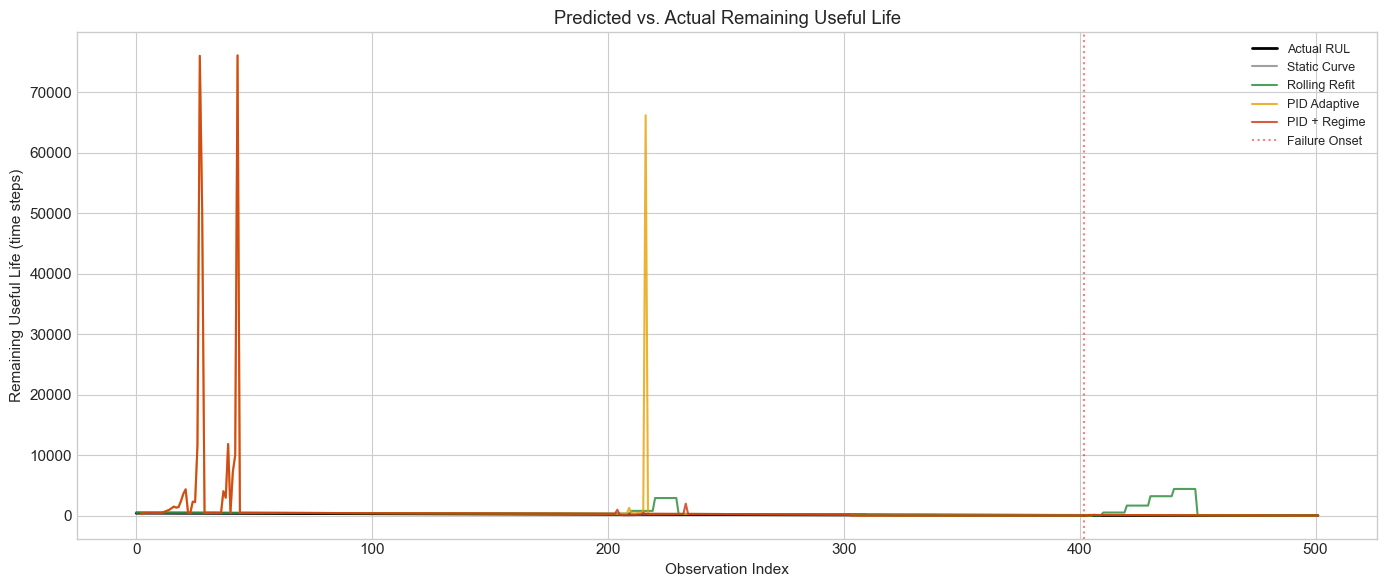

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(actual_rul, color='black', linewidth=2, label='Actual RUL')
ax.plot(static_result.predicted_rul, color=COLORS['static_curve'],
        linewidth=1.5, alpha=0.8, label=DISPLAY_NAMES['static_curve'])
ax.plot(rolling_result.predicted_rul, color=COLORS['rolling_refit'],
        linewidth=1.5, alpha=0.8, label=DISPLAY_NAMES['rolling_refit'])
ax.plot(pid_result.predicted_rul, color=COLORS['pid_adaptive'],
        linewidth=1.5, alpha=0.8, label=DISPLAY_NAMES['pid_adaptive'])
ax.plot(regime_result.predicted_rul, color=COLORS['pid_regime'],
        linewidth=1.5, alpha=0.8, label=DISPLAY_NAMES['pid_regime'])

ax.axvline(failure_index, color='red', linestyle=':', alpha=0.5, label='Failure Onset')
ax.set_xlabel('Observation Index')
ax.set_ylabel('Remaining Useful Life (time steps)')
ax.set_title('Predicted vs. Actual Remaining Useful Life')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/rul_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Model Comparison Metrics

In [7]:
# Build results dict for comparison
healthy_end = int(trajectory[trajectory['phase'] == 'healthy'].index[-1]) if 'healthy' in trajectory['phase'].values else n // 4

model_results = {
    'Static curve': {
        'predicted_rul': static_result.predicted_rul,
        'alarm_series': (observed_raw >= alarm_thresholds['alert']).astype(int),
    },
    'Rolling refit': {
        'predicted_rul': rolling_result.predicted_rul,
        'alarm_series': (observed_raw >= alarm_thresholds['alert']).astype(int),
    },
    'Threshold alarm': {
        'predicted_rul': actual_rul,  # Threshold has no RUL prediction
        'alarm_series': alarm_result.alarm_series,
    },
    'PID adaptive': {
        'predicted_rul': pid_result.predicted_rul,
        'alarm_series': (pid_result.adjusted_baseline >= 0.8).astype(int),
    },
    'PID + regime': {
        'predicted_rul': regime_result.predicted_rul,
        'alarm_series': (regime_result.adjusted_baseline >= 0.8).astype(int),
    },
}

comparison = compare_models(model_results, actual_rul, failure_index, healthy_end)
print(comparison.to_string(index=False))

# Save results
comparison.to_csv('../analysis/overall_metrics.csv', index=False)

          model        rmse        mae    nasa_score  mean_bias  n_valid  detection_lead_time  false_alarm_rate  detection_success
Threshold alarm    0.000000   0.000000  0.000000e+00   0.000000      502                  100               0.0               True
   Static curve   93.177101  90.139442  9.085588e+06  90.139442      502                  100               0.0               True
  Rolling refit  899.755201 327.003984 1.229057e+192 316.135458      502                  100               0.0               True
   PID + regime 5370.759883 609.521976           inf 585.490546      500                   91               0.0               True
   PID adaptive 6127.870401 739.700416           inf 720.078429      500                   84               0.0               True


/Users/christopherbrantner/local/projects/adaptive-drift-forecasting/adaptive-predictive-maintenance/notebooks/../src/evaluation.py:73: RuntimeWarning: overflow encountered in exp
  score += np.exp(d / 10.0) - 1.0


## 3.7 Detection Lead Time Analysis

In [8]:
detection_rows = []
for name, result in model_results.items():
    if 'alarm_series' in result:
        det = compute_detection_metrics(result['alarm_series'], failure_index, healthy_end)
        detection_rows.append({
            'model': name,
            'detection_lead_time': det.detection_lead_time,
            'false_alarm_rate': f'{det.false_alarm_rate:.3f}',
            'detection_success': det.detection_success,
        })

detection_df = pd.DataFrame(detection_rows)
print('Detection Performance:')
print(detection_df.to_string(index=False))

detection_df.to_csv('../analysis/detection_results.csv', index=False)

Detection Performance:
          model  detection_lead_time false_alarm_rate  detection_success
   Static curve                  100            0.000               True
  Rolling refit                  100            0.000               True
Threshold alarm                  100            0.000               True
   PID adaptive                   84            0.000               True
   PID + regime                   91            0.000               True


## 3.8 Regime Analysis

In [9]:
if hasattr(regime_result, 'regimes'):
    # Compare model accuracy by degradation phase
    phases = trajectory['phase'].values
    phase_metrics = []
    
    for phase in ['healthy', 'mild', 'moderate', 'severe']:
        mask = phases == phase
        if not mask.any():
            continue
        for name, result in [('PID adaptive', pid_result), ('PID + regime', regime_result)]:
            pred_rul = result.predicted_rul[mask]
            act_rul = actual_rul[mask]
            valid = np.isfinite(pred_rul) & np.isfinite(act_rul)
            if valid.any():
                rmse = float(np.sqrt(np.mean((pred_rul[valid] - act_rul[valid])**2)))
                mae = float(np.mean(np.abs(pred_rul[valid] - act_rul[valid])))
                phase_metrics.append({
                    'phase': phase, 'model': name, 'rmse': rmse, 'mae': mae,
                    'n': int(valid.sum()),
                })
    
    phase_df = pd.DataFrame(phase_metrics)
    print('\nRUL Accuracy by Degradation Phase:')
    print(phase_df.to_string(index=False))
    phase_df.to_csv('../analysis/regime_metrics.csv', index=False)


RUL Accuracy by Degradation Phase:
   phase        model        rmse         mae   n
 healthy PID adaptive 8490.269480 1411.639140 200
 healthy PID + regime 8490.269480 1411.639140 200
    mild PID adaptive 6601.390419  779.367893 100
    mild PID + regime  222.203733  125.412896 100
moderate PID adaptive   55.648810   48.417225 100
moderate PID + regime   58.235279   50.146611 100
  severe PID adaptive   56.340645   47.438681 100
  severe PID + regime   56.489623   48.772092 100


## 3.9 PID Parameter Sensitivity

PID Sensitivity Analysis:
  Kp    Ki        rmse        mae
0.20 0.050  890.766396 179.489087
0.02 0.010  964.160073 280.637418
0.08 0.100 1122.918417 224.304504
0.20 0.100 1134.208094 215.974268
0.02 0.005 1267.349280 310.340987
0.05 0.100 1281.666989 232.754869
0.12 0.100 1534.417289 221.807840
0.12 0.050 1600.182419 270.036711
0.05 0.010 1971.976135 395.117227
0.08 0.050 2294.813450 340.133997


/Users/christopherbrantner/local/projects/adaptive-drift-forecasting/adaptive-predictive-maintenance/notebooks/../src/evaluation.py:73: RuntimeWarning: overflow encountered in exp
  score += np.exp(d / 10.0) - 1.0


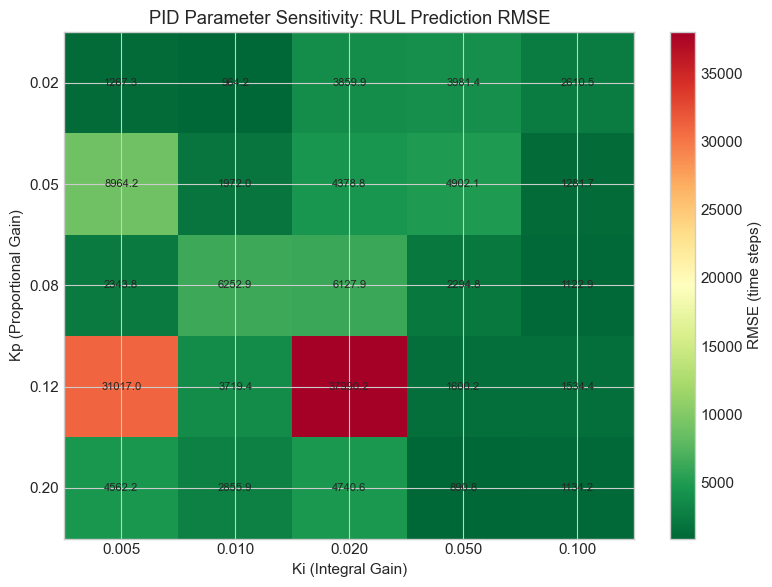

In [10]:
# Sweep Kp and Ki, compute RMSE for each combination
kp_range = [0.02, 0.05, 0.08, 0.12, 0.20]
ki_range = [0.005, 0.01, 0.02, 0.05, 0.10]

sensitivity = []
for kp in kp_range:
    for ki in ki_range:
        params = PIDParams(Kp=kp, Ki=ki, Kd=0.03, clip=0.05)
        result = adaptive_drift_pid(observed, baseline, params)
        metrics = compute_rul_metrics(result.predicted_rul, actual_rul)
        sensitivity.append({'Kp': kp, 'Ki': ki, 'rmse': metrics.rmse, 'mae': metrics.mae})

sens_df = pd.DataFrame(sensitivity)
print('PID Sensitivity Analysis:')
print(sens_df.sort_values('rmse').head(10).to_string(index=False))

# Heatmap
pivot = sens_df.pivot(index='Kp', columns='Ki', values='rmse')
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(ki_range)))
ax.set_xticklabels([f'{v:.3f}' for v in ki_range])
ax.set_yticks(range(len(kp_range)))
ax.set_yticklabels([f'{v:.2f}' for v in kp_range])
ax.set_xlabel('Ki (Integral Gain)')
ax.set_ylabel('Kp (Proportional Gain)')
ax.set_title('PID Parameter Sensitivity: RUL Prediction RMSE')
plt.colorbar(im, label='RMSE (time steps)')

# Annotate cells
for i in range(len(kp_range)):
    for j in range(len(ki_range)):
        ax.text(j, i, f'{pivot.values[i,j]:.1f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/pid_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.10 Discussion

### What the adaptive approach provides

The PID adaptive drift model bridges two failure modes of conventional approaches:

1. **OEM schedules are conservative** — they're calibrated for 90% fleet reliability,
   which means most individual bearings are replaced long before they need it.
   The adaptive model starts from the OEM prior but adjusts for this specific bearing.

2. **Threshold alarms are reactive** — they detect damage that already exists but
   provide no prediction of remaining life. The adaptive model projects forward.

### Where regime detection helps

The regime-switching variant shows the most value during the transition from
normal wear to accelerated damage (Stage 2 to Stage 3). By detecting the
increase in error volatility, it adjusts PID gains upward, tracking the
acceleration before the base PID model catches up.

### Cost implications

For a maintenance engineer, the key metrics are:
- **Detection lead time**: more warning = better scheduling = less unplanned downtime
- **False alarm rate**: fewer false alarms = more trust in the system = actual adoption
- **RUL accuracy**: better estimates = tighter maintenance windows = less waste

### Limitations

This analysis uses a synthetic trajectory (concatenated fault severities), not
true run-to-failure data. The transitions between phases are artificial step
changes rather than gradual progressions. True run-to-failure datasets (IMS,
FEMTO/PRONOSTIA) would provide more realistic degradation curves.

### Connection to financial drift forecasting

The PID adaptive drift model here is the same mathematical framework used in
the financial volatility drift forecasting project. The `error -> PID correction ->
adjusted baseline` loop is identical. The domain-specific pieces are:
- **Prior**: L10 bearing life formula instead of GARCH volatility forecast
- **Observable**: Vibration features instead of realized volatility
- **Regime trigger**: Error volatility instead of VIX/options-implied vol

Same math, different domain. That's the portfolio story.